In [16]:
from pandas import read_csv, DataFrame
from seaborn import histplot, countplot, boxplot, heatmap, scatterplot, barplot
from matplotlib.pyplot import xticks, figure, xlabel, ylabel, show, title, subplot, tight_layout, plot, grid, legend, subplots
from numpy import cumsum
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score 

from model.perceptron import Perceptron

In [17]:
dataframe_raw = read_csv('../data/raw/bcw_data_raw.csv', )
dataframe_raw.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [18]:
dataframe_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

/tmp/ipykernel_66616/2833261013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  countplot(x=dataframe_raw["diagnosis"], palette=["#1f77b4", "#ff7f0e"])


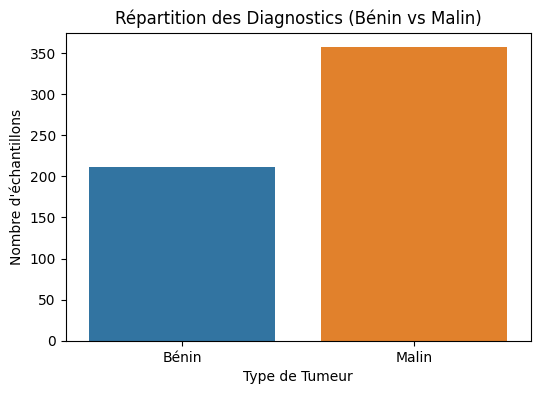

In [19]:
figure(figsize=(6,4))
countplot(x=dataframe_raw["diagnosis"], palette=["#1f77b4", "#ff7f0e"])
xticks(ticks=[0,1], labels=["Bénin", "Malin"])
xlabel("Type de Tumeur")
ylabel("Nombre d'échantillons")
title("Répartition des Diagnostics (Bénin vs Malin)")
show()

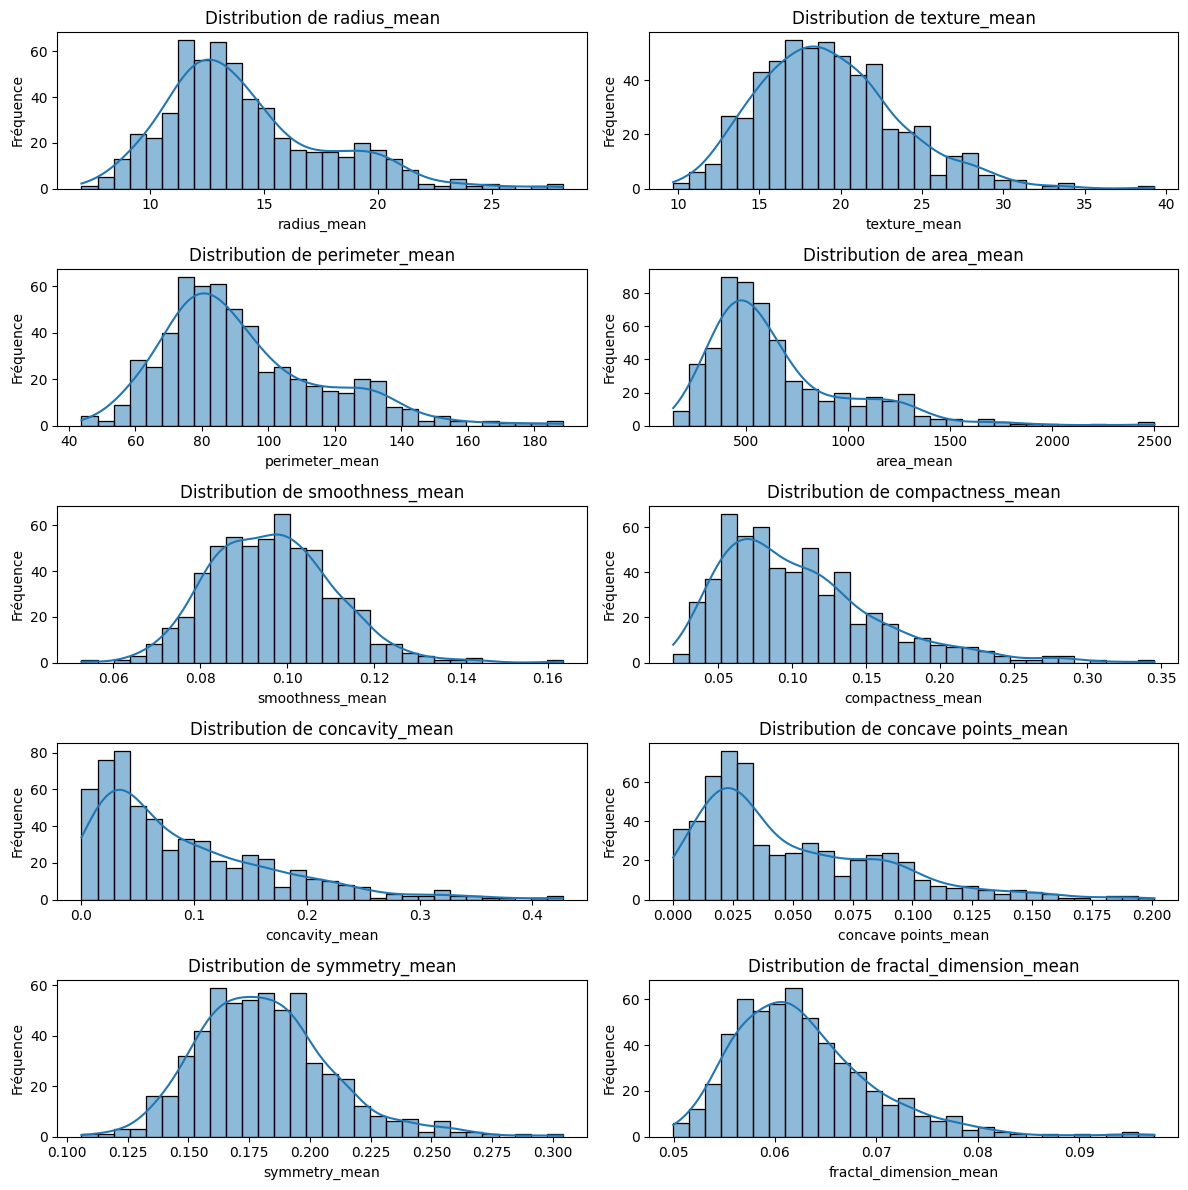

In [20]:

MEAN_COLUMNS = ['radius_mean', 'texture_mean','perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
figure(figsize=(12, 12))

for i, feature in enumerate(MEAN_COLUMNS, 1):
    subplot(5, 2, i)
    histplot(dataframe_raw[feature], kde=True, bins=30, color="#1f77b4")
    title(f"Distribution de {feature}")
    xlabel(feature)
    ylabel("Fréquence")

tight_layout()
show()

/tmp/ipykernel_66616/4282455516.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot(x=dataframe_raw["diagnosis"], y=dataframe_raw[feature], palette=["#1f77b4", "#ff7f0e"])
/tmp/ipykernel_66616/4282455516.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot(x=dataframe_raw["diagnosis"], y=dataframe_raw[feature], palette=["#1f77b4", "#ff7f0e"])
/tmp/ipykernel_66616/4282455516.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot(x=dataframe_raw["diagnosis"], y=dataframe_raw[feature], palette=["#1f77b4", "#ff7f0e"])
/tmp/ipykernel_66616/4282455516.py:5: Futur

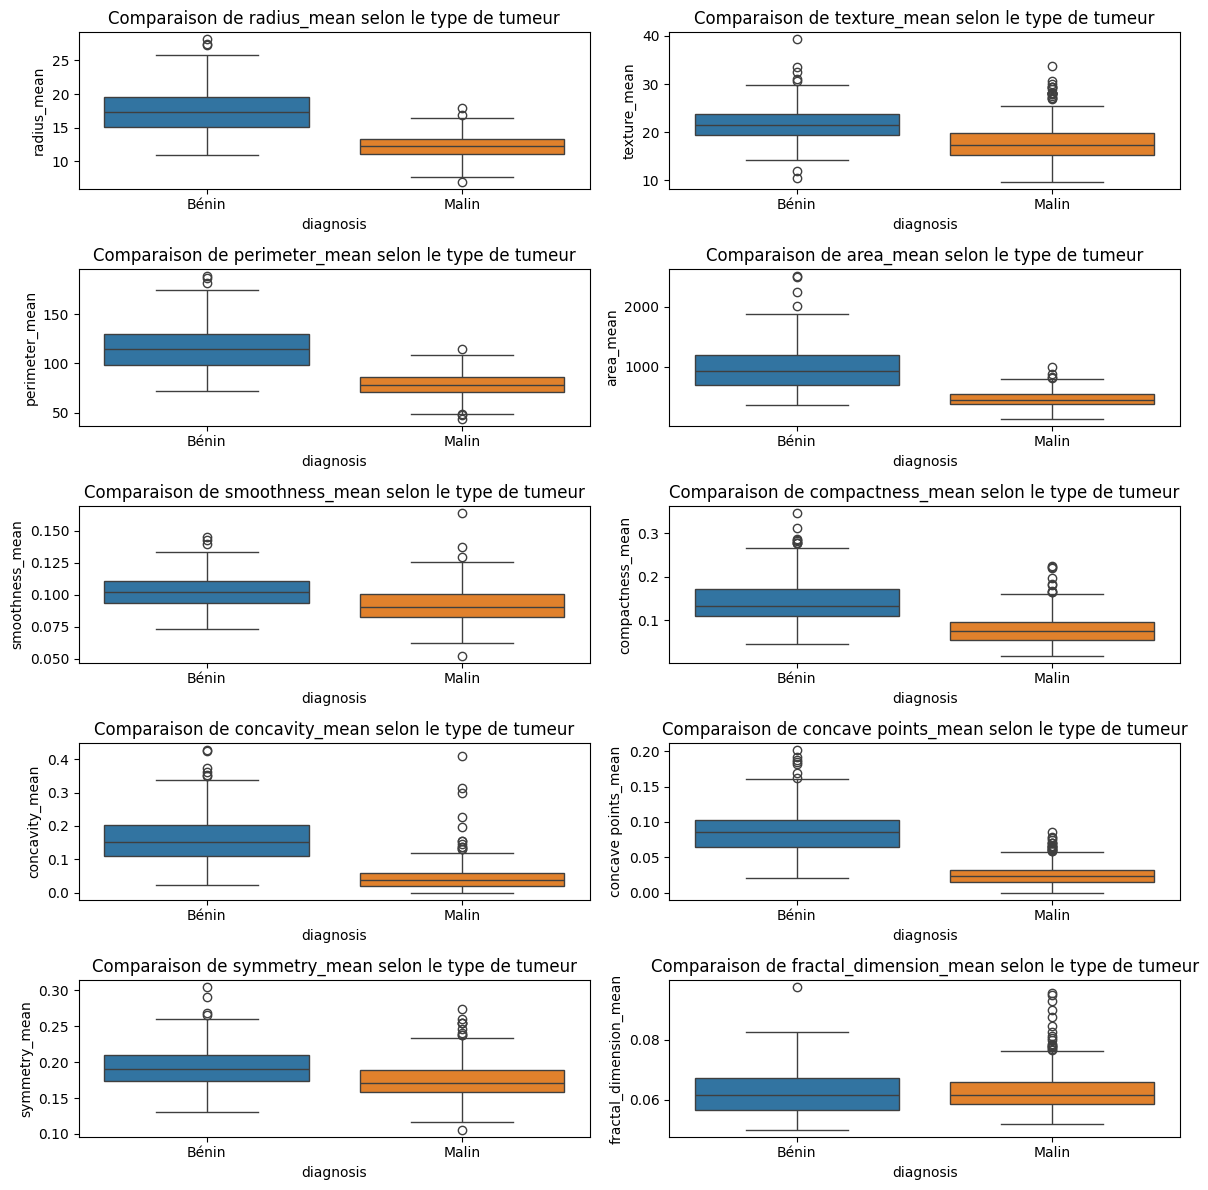

In [21]:
figure(figsize=(12, 12))

for i, feature in enumerate(MEAN_COLUMNS, 1):
    subplot(5, 2, i)
    boxplot(x=dataframe_raw["diagnosis"], y=dataframe_raw[feature], palette=["#1f77b4", "#ff7f0e"])
    xticks(ticks=[0,1], labels=["Bénin", "Malin"])
    title(f"Comparaison de {feature} selon le type de tumeur")

tight_layout()
show()

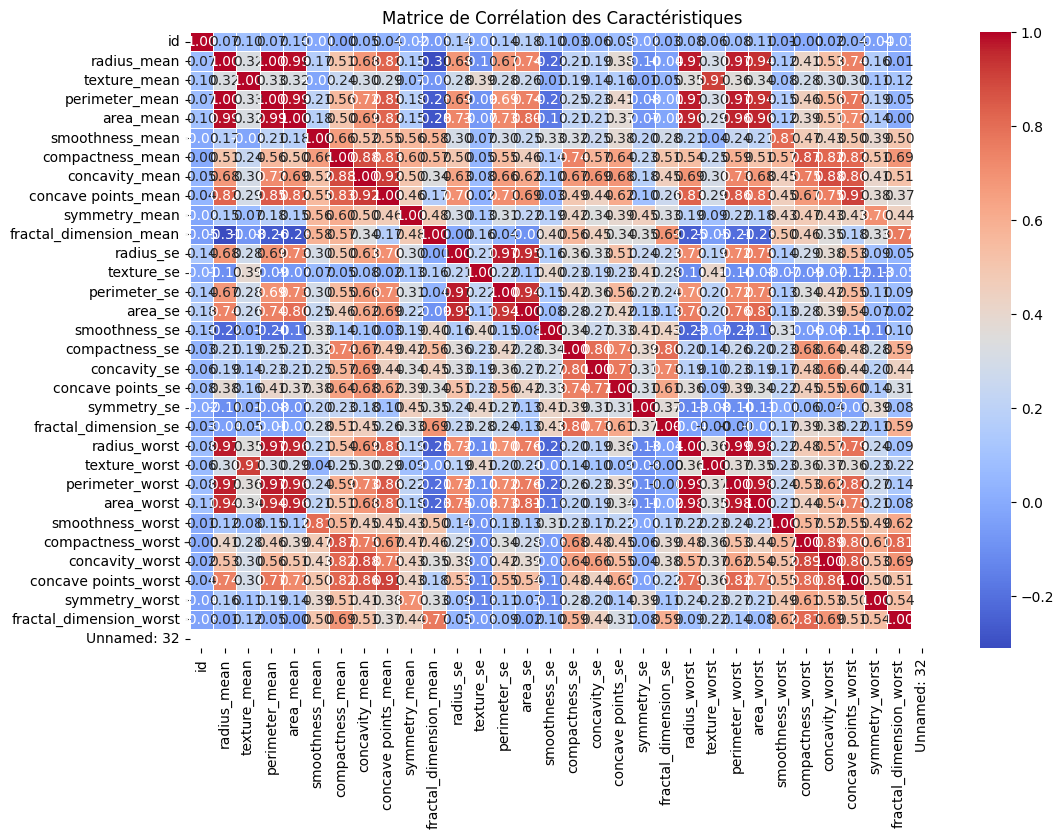

In [22]:
corr_matrix = dataframe_raw.drop(columns="diagnosis").corr()
figure(figsize=(12, 8))
heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
title("Matrice de Corrélation des Caractéristiques")
show()

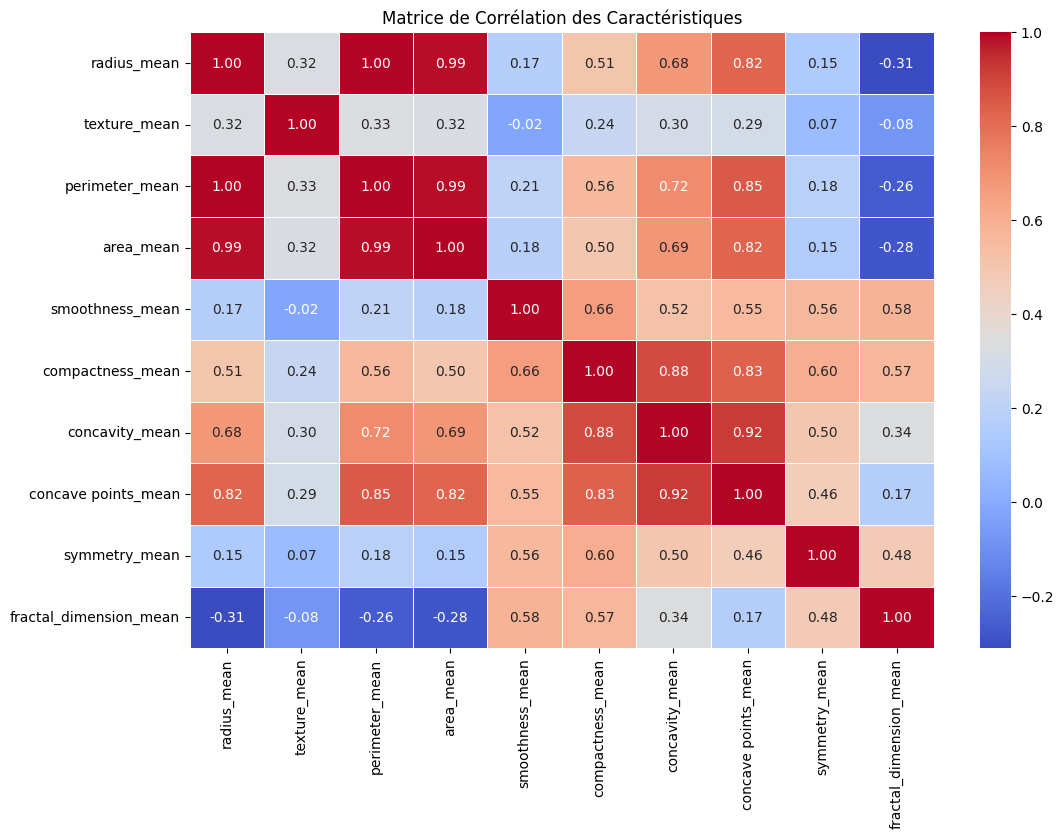

In [23]:
corr_matrix = dataframe_raw[MEAN_COLUMNS].corr()
figure(figsize=(12, 8))
heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
title("Matrice de Corrélation des Caractéristiques")
show()

## Répartition des diagnostics :  

Le dataset contient une majorité de tumeurs bénignes par rapport aux tumeurs malignes.  
Cela peut potentiellement influencer un modèle de classification s'il n'est pas bien équilibré.  
## Analyse des distributions :  

Les tumeurs bénignes ont en moyenne des périmètres (perimeter_mean) et des rayons (radius_mean) plus petits que les tumeurs malignes.  
La distribution de certaines caractéristiques est asymétrique, suggérant la présence de valeurs extrêmes.  
## Comparaison des caractéristiques par type de tumeur :  

Les boxplots montrent que les tumeurs malignes ont une plus grande variabilité dans leurs caractéristiques (rayon, périmètre, concavité, etc.), alors que les valeurs des tumeurs bénignes sont plus concentrées.  
La différence entre les médianes est marquée, ce qui indique que ces variables peuvent être de bons indicateurs pour différencier les deux types de tumeurs.  

## Corrélation entre les variables :

On observe une forte corrélation entre le périmètre (perimeter_mean) et le rayon (radius_mean), ce qui est logique puisque le périmètre est directement lié au rayon d'une cellule tumorale.  
D'autres corrélations élevées apparaissent entre des caractéristiques similaires (ex : area_mean et radius_mean), suggérant qu’un sous-ensemble réduit de variables pourrait suffire à caractériser les tumeurs.  

## Relations entre les caractéristiques  :

Le pairplot met en évidence une séparation visible entre les tumeurs bénignes et malignes dans certaines dimensions, notamment radius_mean et concavity_mean.  
Cela indique que ces caractéristiques sont de bons candidats pour une classification efficace à l'aide d'un modèle supervisé.  

***

L’analyse montre que les caractéristiques géométriques des cellules tumorales (rayon, périmètre, concavité) sont des indicateurs clés pour différencier les tumeurs bénignes des tumeurs malignes.  
La forte corrélation entre certaines variables suggère une réduction de dimensions (comme PCA). 

In [24]:
dataframe = read_csv('../data/preprocess/bcw_data_preprocess.csv')
dataframe.drop(columns=['Unnamed: 0'], inplace=True)

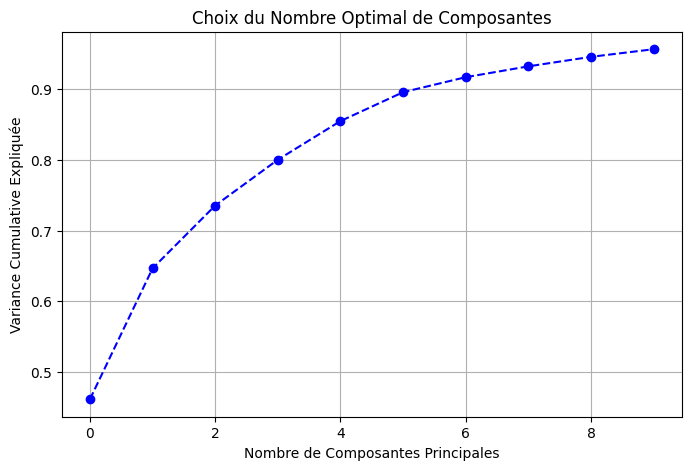

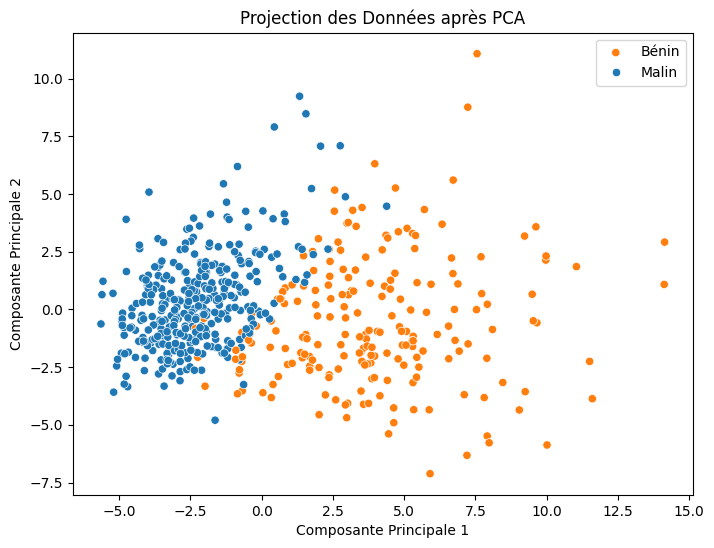

In [25]:
bcw_data, diagnosis = dataframe.drop(columns=["diagnosis"]), dataframe["diagnosis"]
pca = PCA(n_components=10) 
data_pca = pca.fit_transform(bcw_data)

# Elbow Chat
figure(figsize=(8, 5))
plot(cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
xlabel("Nombre de Composantes Principales")
ylabel("Variance Cumulative Expliquée")
title("Choix du Nombre Optimal de Composantes")
grid()
show()

pca = PCA(n_components=2) 
data_pca = pca.fit_transform(bcw_data)
# Figure with two principal components
figure(figsize=(8, 6))
scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=diagnosis, palette=["#1f77b4", "#ff7f0e"])
xlabel("Composante Principale 1")
ylabel("Composante Principale 2")
title("Projection des Données après PCA")
legend(labels=["Bénin", "Malin"])
show()


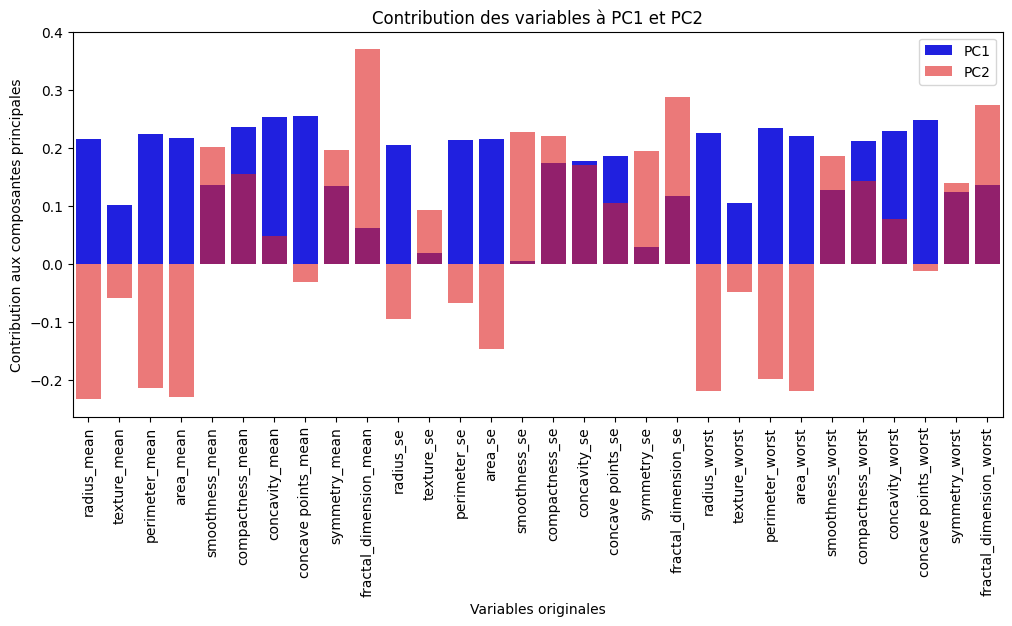

In [26]:
loadings = pca.components_.T 
features = bcw_data.columns

pca_loadings_df = DataFrame(loadings, index=features, columns=["PC1", "PC2"])

figure(figsize=(12, 5))
barplot(x=pca_loadings_df.index, y=pca_loadings_df["PC1"], color="b", label="PC1")
barplot(x=pca_loadings_df.index, y=pca_loadings_df["PC2"], color="r", alpha=0.6, label="PC2")
xticks(rotation=90)
xlabel("Variables originales")
ylabel("Contribution aux composantes principales")
title("Contribution des variables à PC1 et PC2")
legend()
show()

In [27]:


perceptron = Perceptron(2)
dataframe_train, dataframe_test, diagnosis_train, diagnosis_test = train_test_split(dataframe, diagnosis, test_size=0.33, random_state=42)

dataframe_train, dataframe_test = pca.fit_transform(dataframe_train), pca.fit_transform(dataframe_test) 
perceptron.fit(dataframe_train, diagnosis_train)
prediction = perceptron.predict(dataframe_test)

print(f"Accuracy du Perceptron : {accuracy_score(diagnosis_test, prediction)}")
print(f"Precision du Perceptron : {precision_score(diagnosis_test, prediction)}")
print(f"Sensibilité du Perceptron : {recall_score(diagnosis_test, prediction)}")
print(f"Moyenne harmonique (f1_score) du Perceptron : {f1_score(diagnosis_test, prediction)}")

Accuracy du Perceptron : 0.9459459459459459
Precision du Perceptron : 0.9852941176470589
Sensibilité du Perceptron : 0.881578947368421
Moyenne harmonique (f1_score) du Perceptron : 0.9305555555555556


# Conclusion
Avec de très bon résultats (excellente précision avec une très bonne sensibilité), on constate que le perceptron est efficace pour les problématiques de classification binaire avec peu de components.  
Pour améliorer ces résultats, on peut imaginer avec plus de données ou même créer plusieurs couches de Perceptron.